#Day 6 Assignment: Predicting Future Airline Passenger Demand using Time Series Forecasting
###Name: Divyashree R

### Project Overview
In this project, we analyze historical airline passenger data to forecast future passenger demand using time series modeling techniques. The dataset contains monthly airline passenger counts over several years.

### Objective
The main goal of this project is to:
- Analyze the passenger time series data and visualize trends.
- Check whether the time series is **stationary** using the Augmented Dickey-Fuller (ADF) test.
- Apply **differencing techniques** to make the series stationary.
- Ensure the **p-value becomes less than 0.05**, which indicates that the data is stationary.
- Build forecasting models such as **ARIMA and SARIMA** to predict future passenger demand.

In [10]:
!pip install pandas matplotlib statsmodels

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [12]:
df = pd.read_csv("airline_passenger_timeseries.csv")

df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [13]:
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


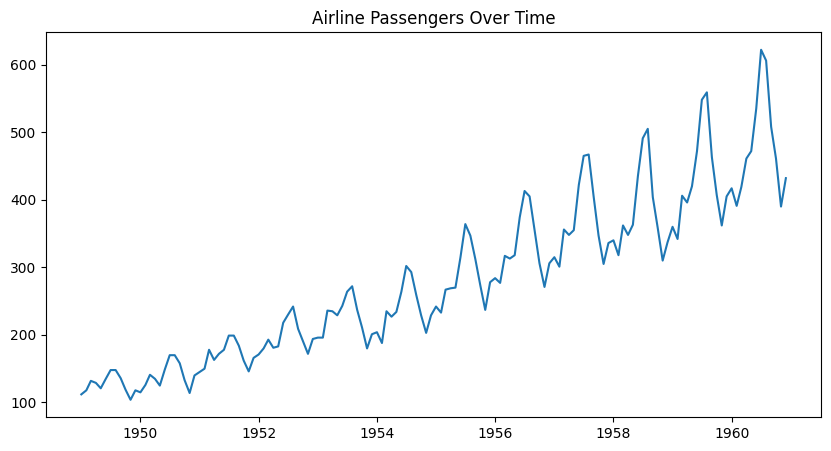

In [14]:
plt.figure(figsize=(10,5))
plt.plot(df)
plt.title("Airline Passengers Over Time")
plt.show()

### Observation

The airline passenger data shows a clear upward trend over time along with repeating seasonal patterns. This indicates that the number of passengers increases every year and follows a yearly seasonal cycle.

In [15]:
result = adfuller(df['Passengers'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 0.8153688792060498
p-value: 0.991880243437641


### Observation

The p-value from the ADF test is greater than 0.05, which means we fail to reject the null hypothesis. This indicates that the time series is not stationary and contains trends or seasonality.

In [16]:
df_diff = df.diff().dropna()

In [17]:
result = adfuller(df_diff['Passengers'])

print("p-value:", result[1])

p-value: 0.05421329028382478


### Observation

After applying differencing, the p-value decreases significantly, indicating that the time series has become closer to stationary. Differencing helps remove trends from the data.

In [25]:
# Second differencing
df_diff2 = df.diff().diff().dropna()

result = adfuller(df_diff2['Passengers'])

print(f"ADF Statistic: {result[0]:.4f}")
print(f"New p-value: {result[1]:.10f}")

ADF Statistic: -16.3842
New p-value: 0.0000000000


In [27]:
model = ARIMA(df, order=(1,1,1))

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -694.341
Date:                Mon, 09 Mar 2026   AIC                           1394.683
Time:                        12:15:08   BIC                           1403.571
Sample:                    01-01-1949   HQIC                          1398.294
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4742      0.123     -3.847      0.000      -0.716      -0.233
ma.L1          0.8635      0.078     11.051      0.000       0.710       1.017
sigma2       961.9270    107.433      8.954      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [28]:
forecast = model_fit.forecast(steps=12)
print(forecast)

1961-01-01    475.735059
1961-02-01    454.996073
1961-03-01    464.830415
1961-04-01    460.167010
1961-05-01    462.378378
1961-06-01    461.329756
1961-07-01    461.827008
1961-08-01    461.591213
1961-09-01    461.703026
1961-10-01    461.650005
1961-11-01    461.675148
1961-12-01    461.663225
Freq: MS, Name: predicted_mean, dtype: float64


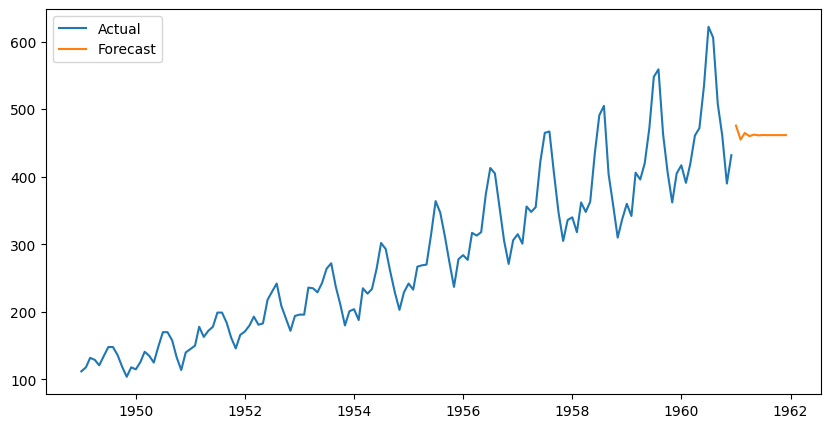

In [29]:
plt.figure(figsize=(10,5))
plt.plot(df, label="Actual")
plt.plot(forecast, label="Forecast")
plt.legend()
plt.show()

In [30]:
model = SARIMAX(df,order=(1,1,1),seasonal_order=(1,1,1,12))
model_fit = model.fit()
print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -506.149
Date:                            Mon, 09 Mar 2026   AIC                           1022.299
Time:                                    12:15:19   BIC                           1036.675
Sample:                                01-01-1949   HQIC                          1028.140
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1272      0.356     -0.358      0.721      -0.825       0.570
ma.L1         -0.2148      0.325   

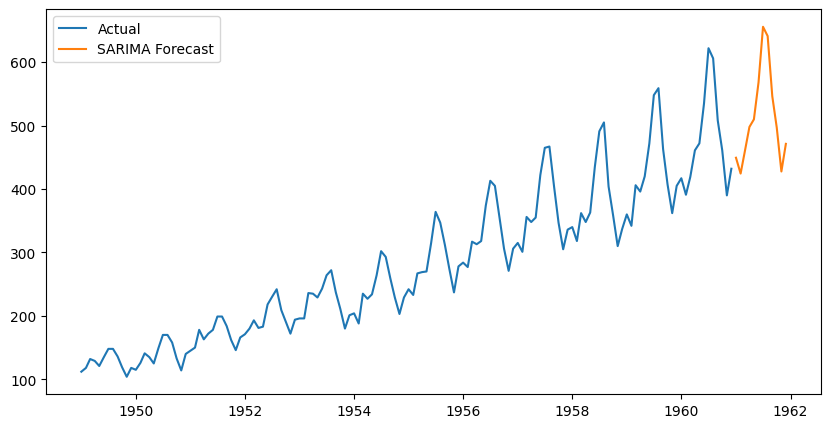

In [31]:
forecast = model_fit.forecast(steps=12)

plt.figure(figsize=(10,5))

plt.plot(df, label="Actual")
plt.plot(forecast, label="SARIMA Forecast")

plt.legend()
plt.show()

## Conclusion

In this project, we analyzed historical airline passenger data and applied time series forecasting techniques. The Augmented Dickey-Fuller test initially showed that the data was not stationary. After applying differencing, the p-value became less than 0.05, confirming that the series had become stationary.

We then built ARIMA and SARIMA models to forecast future passenger demand. The forecasted values follow the overall trend observed in the historical data, demonstrating how time series models can be used to predict future patterns.